# Segment Contribution Analysis


## Load data

1. Aggregate transaction-level data.
To make the analysis more meaningful, I introduced controlled perturbations to simulate noticeable growth patterns.

2. Select a target merchant and benchmark key business metrics (e.g., transaction amount, transaction count) against peer merchants within the same category.

In [1]:
import pandas as pd
import numpy as np
import etl
from exhaustive_segment_search import exhaustive_eval
from config import DIMENSION_COLS
from helper import plot_waterfall

In [2]:
TARGET_MERCHANTS = "fraud_Kilback LLC" # A merchant with good growth that beat peers.
# TARGET_MERCHANTS = "fraud_Champlin, Rolfson and Connelly" # A merchant with negative growth that underperforms peers.
target_col = "amt_growth_ctc_diff"
dim_cols = DIMENSION_COLS

df_combined = etl.load_rca_data(TARGET_MERCHANTS)

File exists, loading data from /Users/yanxinye/github/competency-intelligence/src/segment_analysis/etl/rca_fraud_Kilback LLC.csv...


## Segment-Level Decomposition

### Option1: Exhaustive Search of All Dimension Interactions

An intuitive approach to identifying segments that explain the gap between a target merchant and its peers is to compute metrics across all combinations of dimension columns (i.e., k-way interactions).

In [3]:
sorted_res = exhaustive_eval(df_combined, target_col, dim_cols=dim_cols)

total = df_combined[target_col].sum()
print(f"The total growth difference is: {total:.2%}")
print("Top segment drivers:\n")
for i, (k, v) in enumerate(sorted_res[:20], 1):
    print(f"{i:>2}. {k:<50} | {v:>8.2%} | contribution: {v/total:>6.2%}")

The total growth difference is: -8.27%
Top segment drivers:

 1. gender = M, category = grocery_pos                 |  -18.19% | contribution: 219.82%
 2. category = grocery_pos, market = Midwest           |  -15.69% | contribution: 189.65%
 3. category = grocery_pos                             |  -15.63% | contribution: 188.91%
 4. gender = M                                         |  -13.63% | contribution: 164.72%
 5. market = Midwest                                   |  -12.22% | contribution: 147.67%
 6. generation = Millennial, gender = M, category = grocery_pos |  -10.87% | contribution: 131.36%
 7. generation = Millennial, category = grocery_pos    |  -10.68% | contribution: 129.13%
 8. category = grocery_pos, market = Northeast         |   -9.36% | contribution: 113.08%
 9. generation = Gen X, market = Midwest               |   -9.14% | contribution: 110.47%
10. generation = Gen X, category = grocery_pos, market = Midwest |   -8.39% | contribution: 101.41%
11. gender = F, cate


This results in **O(2ⁿ)** complexity, with computational cost growing exponentially as the number of dimensions increases.

To maintain tractability, we can cap the interaction depth (e.g., *k ≤ 3*), trading off computational efficiency against the ability to capture higher-order interactions.

### Option2: Tree search

In [4]:
from tree_search import TreeForest



forest = TreeForest(
    df_combined,
    target_col,
    DIMENSION_COLS,
    n_trees=3,
    max_coverage=0.2,
    max_depth=4,
)
forest.construct_forest()







Learned key drivers from the forest:
Peer growth contribution: 99.97%
Target growth contribution: 91.70%

Key drivers and their contributions:
Peer Benchmark                 |   99.97% | contribution: 109.02%
generation = Millennial|gender = M|category = grocery_pos|market = Northeast |  -10.87% | contribution: -11.85%
generation = Millennial|gender = F|category = grocery_pos|market = South |    9.30% | contribution: 10.15%
generation = Gen X|gender = F|category = grocery_pos|market = Midwest |   -8.39% | contribution: -9.15%
Other                          |    1.68% | contribution:  1.83%
Target (fraud_Kilback LLC)     |   91.70% | contribution: 100.00%


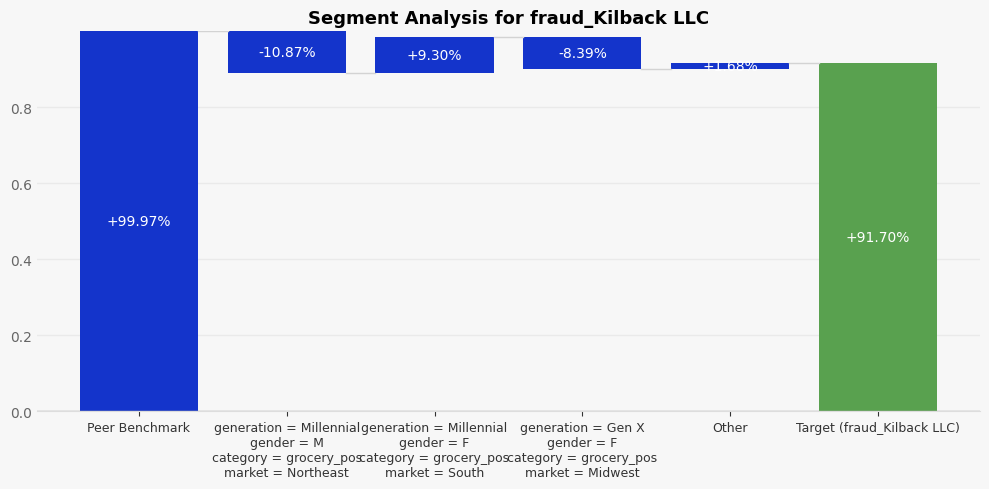

In [5]:
print("\nLearned key drivers from the forest:")
dim, val = forest.collect_key_drivers()
peer_score = df_combined["amt_growth_ctc_peer"].sum()
target_score = df_combined["amt_growth_ctc"].sum()
print(f"Peer growth contribution: {peer_score:.2%}")
print(f"Target growth contribution: {target_score:.2%}")
dim = ["Peer Benchmark"] + dim + [f"Target ({TARGET_MERCHANTS})"]
val = [peer_score] + val + [target_score]
print("\nKey drivers and their contributions:")
for d, v in zip(dim, val):
    print(f"{d:<30} | {v:>8.2%} | contribution: {v/target_score:>6.2%}")

plot_waterfall(dim, val, title=f"Segment Analysis for {TARGET_MERCHANTS}")